In [2]:
import xarray as xr
import matplotlib.pyplot as plt


In [14]:
ds_target = xr.open_dataset('model_ready_data/target_aligned.nc')
ds_sst = xr.open_dataset('model_ready_data/sst_aligned.nc')
ds_ssh = xr.open_dataset('model_ready_data/ssh_aligned.nc')
ds_sss = xr.open_dataset('model_ready_data/sss_aligned.nc')
ds_winds = xr.open_dataset("model_ready_data/winds_aligned.nc")
ds_currents = xr.open_dataset('model_ready_data/currents_aligned.nc')
ds_mask = xr.open_dataset('model_ready_data/official_landmask.nc')

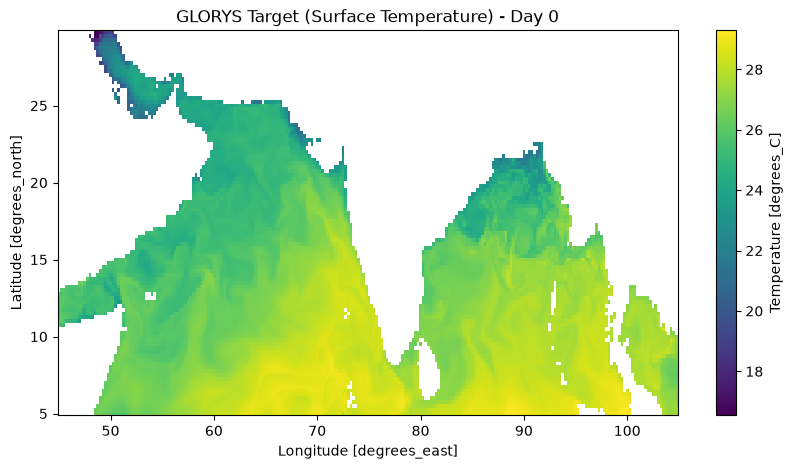

Total Pixels: 24000
NaN (Land) Count: 12168
Valid Ocean Count: 11832


In [5]:
# 1. Target Data (Ground Truth)
# GLORYS has a depth dimension, so we strictly select the surface layer (depth=0)
da_target = ds_target['thetao'].isel(time=0, depth=0)

da_target.plot(cmap='viridis', figsize=(10, 5))
plt.title('GLORYS Target (Surface Temperature) - Day 0')
plt.show()

nans = int(da_target.isnull().sum())
valids = int(da_target.notnull().sum())
print(f"Total Pixels: {nans + valids}")
print(f"NaN (Land) Count: {nans}")
print(f"Valid Ocean Count: {valids}")

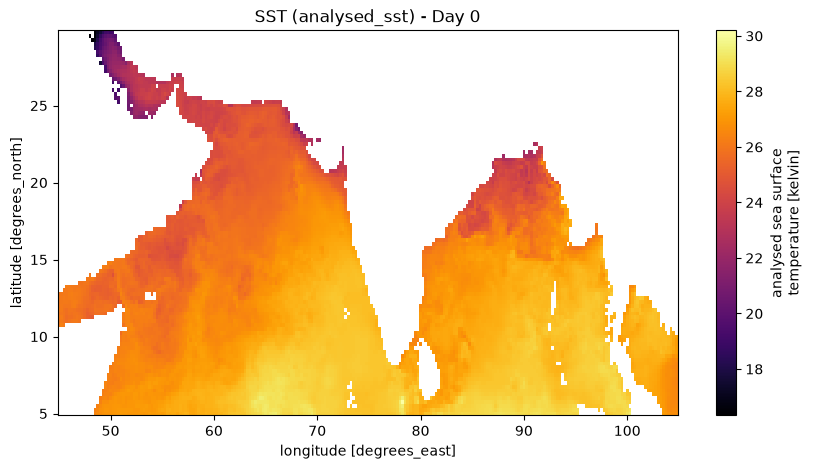

Total Pixels: 24000
NaN (Land) Count: 12186
Valid Ocean Count: 11814


In [6]:
# 2. Sea Surface Temperature
var_sst = list(ds_sst.data_vars)[0]
da_sst = ds_sst[var_sst].isel(time=0)

da_sst.plot(cmap='inferno', figsize=(10, 5))
plt.title(f'SST ({var_sst}) - Day 0')
plt.show()

nans = int(da_sst.isnull().sum())
valids = int(da_sst.notnull().sum())
print(f"Total Pixels: {nans + valids}")
print(f"NaN (Land) Count: {nans}")
print(f"Valid Ocean Count: {valids}")

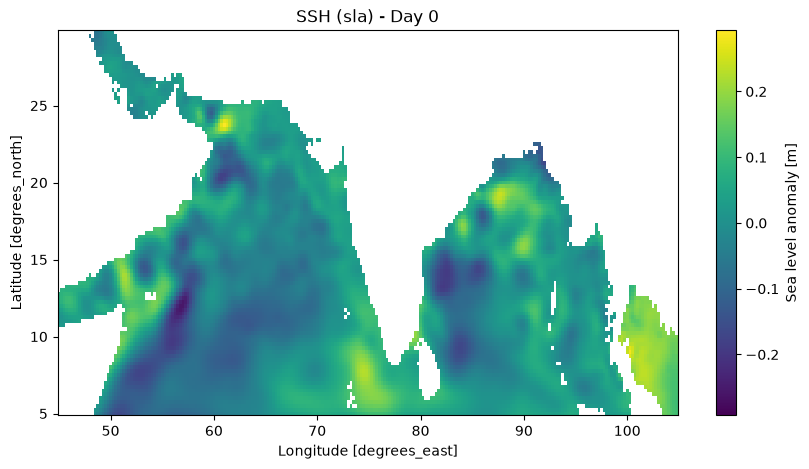

Total Pixels: 24000
NaN (Land) Count: 12171
Valid Ocean Count: 11829


In [10]:
# 3. Sea Surface Height / Anomaly
var_ssh = list(ds_ssh.data_vars)[0]
da_ssh = ds_ssh[var_ssh].isel(time=0)

# Swapped 'mako' for 'viridis' (native to matplotlib)
da_ssh.plot(cmap='viridis', figsize=(10, 5))
plt.title(f'SSH ({var_ssh}) - Day 0')
plt.show()

nans = int(da_ssh.isnull().sum())
valids = int(da_ssh.notnull().sum())
print(f"Total Pixels: {nans + valids}")
print(f"NaN (Land) Count: {nans}")
print(f"Valid Ocean Count: {valids}")

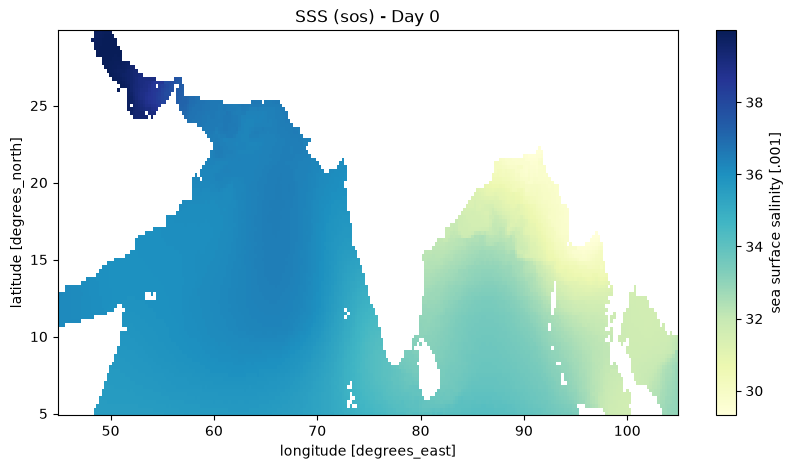

Total Pixels: 24000
NaN (Land) Count: 12307
Valid Ocean Count: 11693


In [11]:
# 4. Sea Surface Salinity
var_sss = list(ds_sss.data_vars)[0]
da_sss = ds_sss[var_sss].isel(time=0)

# Swapped 'haline' for 'YlGnBu' (native to matplotlib)
da_sss.plot(cmap='YlGnBu', figsize=(10, 5))
plt.title(f'SSS ({var_sss}) - Day 0')
plt.show()

nans = int(da_sss.isnull().sum())
valids = int(da_sss.notnull().sum())
print(f"Total Pixels: {nans + valids}")
print(f"NaN (Land) Count: {nans}")
print(f"Valid Ocean Count: {valids}")

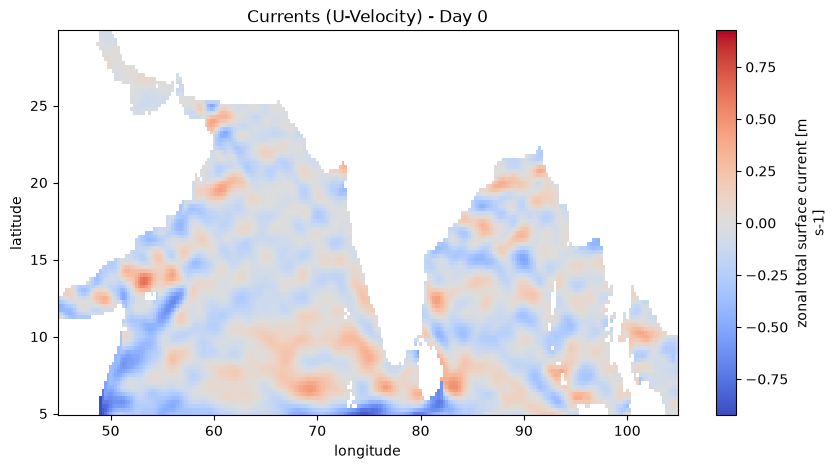

Total Pixels: 24000
NaN (Land) Count: 12549
Valid Ocean Count: 11451


In [9]:
# 5. Ocean Currents (U-Component)
# Using 'u' specifically to check one directional vector
da_currents = ds_currents['u'].isel(time=0)

da_currents.plot(cmap='coolwarm', figsize=(10, 5))
plt.title('Currents (U-Velocity) - Day 0')
plt.show()

nans = int(da_currents.isnull().sum())
valids = int(da_currents.notnull().sum())
print(f"Total Pixels: {nans + valids}")
print(f"NaN (Land) Count: {nans}")
print(f"Valid Ocean Count: {valids}")

--- Rogue NaN Verification ---
A structurally perfect dataset will output exactly 0 for all and contain NO red pixels.

GLORYS Target   | Rogue NaNs in Ocean: 0
SST             | Rogue NaNs in Ocean: 18
SSH             | Rogue NaNs in Ocean: 3
SSS             | Rogue NaNs in Ocean: 139
Currents        | Rogue NaNs in Ocean: 381
Winds           | Rogue NaNs in Ocean: 0


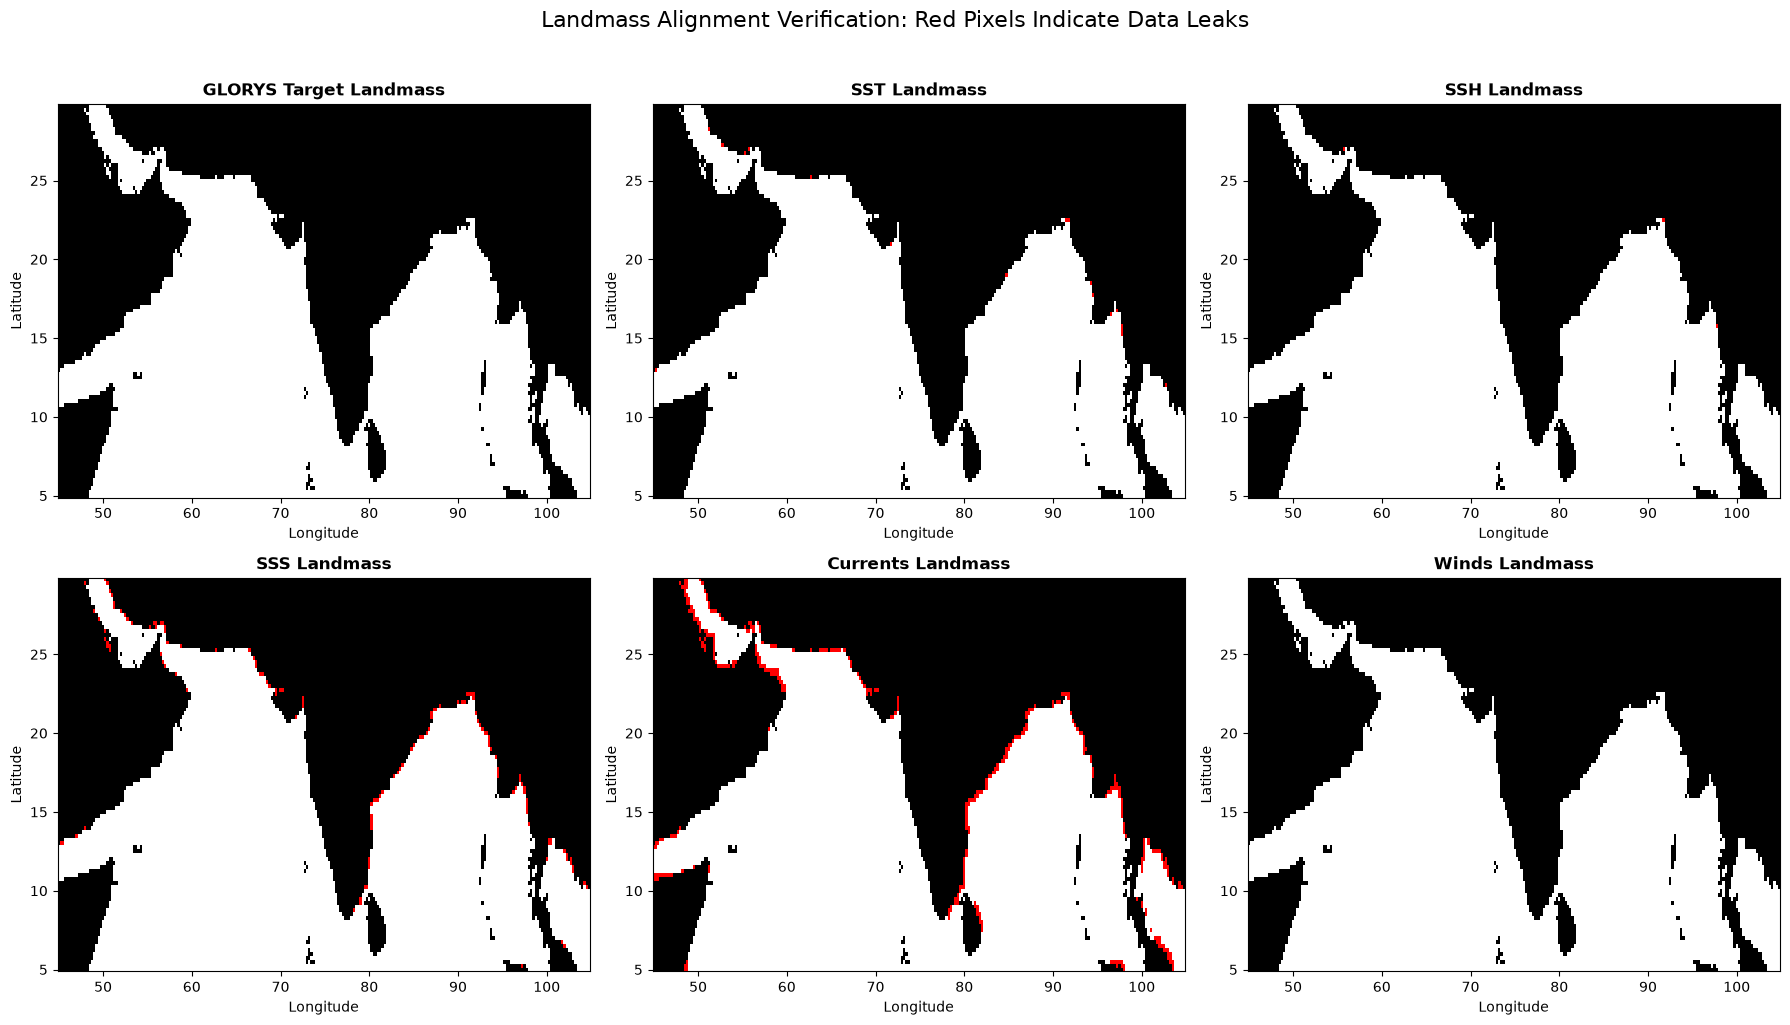

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import xarray as xr

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Map titles to their specific data array slices
datasets = [
    ('GLORYS Target', ds_target['thetao'].isel(time=0, depth=0)),
    ('SST', ds_sst[list(ds_sst.data_vars)[0]].isel(time=0)),
    ('SSH', ds_ssh[list(ds_ssh.data_vars)[0]].isel(time=0)),
    ('SSS', ds_sss[list(ds_sss.data_vars)[0]].isel(time=0)),
    ('Currents', ds_currents[list(ds_currents.data_vars)[0]].isel(time=0)),
    ('Winds', ds_winds[list(ds_winds.data_vars)[0]].isel(time=0))
]

# Custom colormap mapping: 
# 0 = White (Valid Ocean)
# 1 = Black (Expected GLORYS Landmass)
# 2 = Red   (Rogue NaNs in Ocean Space)
cmap = ListedColormap(['white', 'black', 'red'])

# Define the absolute ground truth ocean mask directly from the target DataArray
# True = Valid Ocean, False = Land
master_ocean_mask = ds_target['thetao'].isel(time=0, depth=0).notnull()

print("--- Rogue NaN Verification ---")
print("A structurally perfect dataset will output exactly 0 for all and contain NO red pixels.\n")

for i, (title, da) in enumerate(datasets):
    # 1. Generate base categories: 0 for Ocean (mask=True), 1 for Land (mask=False)
    cat_map = xr.where(master_ocean_mask == False, 1, 0)
    
    # 2. Identify Rogue NaNs: Data is missing BUT the master mask dictates it must be ocean
    rogue_nans_mask = da.isnull() & (master_ocean_mask == True)
    
    # 3. Override Rogue NaN coordinates with category 2 (Red)
    cat_map = xr.where(rogue_nans_mask, 2, cat_map)
    
    # Plot the categorical matrix
    cat_map.plot(ax=axes[i], cmap=cmap, add_colorbar=False, vmin=0, vmax=2)
    axes[i].set_title(f'{title} Landmass', fontweight='bold')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    
    # Calculate and print exact rogue pixel counts
    rogue_nans_count = int(rogue_nans_mask.sum().item())
    print(f"{title:15} | Rogue NaNs in Ocean: {rogue_nans_count}")

plt.suptitle('Landmass Alignment Verification: Red Pixels Indicate Data Leaks', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
target = xr.open_dataset("ml_ready_tensors/target_normalized.nc")
target

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 8035, depth: 15, latitude: 100, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 64kB 2001-01-01 2001-01-02 ... 2022-12-31
  * depth      (depth) int32 60B 0 5 10 20 30 50 75 ... 150 200 300 500 700 1000
  * latitude   (latitude) float32 400B 5.0 5.25 5.5 5.75 ... 29.25 29.5 29.75
  * longitude  (longitude) float32 960B 45.0 45.25 45.5 ... 104.2 104.5 104.8
Data variables:
    thetao     (time, depth, latitude, longitude) float32 12GB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [4]:
features = xr.open_dataset("ml_ready_tensors/features_normalized.nc")
features

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 8035, latitude: 100, longitude: 240)
Coordinates:
  * time          (time) datetime64[ns] 64kB 2001-01-01 ... 2022-12-31
  * latitude      (latitude) float32 400B 5.0 5.25 5.5 5.75 ... 29.25 29.5 29.75
  * longitude     (longitude) float32 960B 45.0 45.25 45.5 ... 104.2 104.5 104.8
    depth         int32 4B ...
Data variables:
    analysed_sst  (time, latitude, longitude) float32 771MB ...
    sos           (time, latitude, longitude) float32 771MB ...
    sla           (time, latitude, longitude) float32 771MB ...
    uwnd          (time, latitude, longitude) float32 771MB ...
    vwnd          (time, latitude, longitude) float32 771MB ...
    u             (time, latitude, longitude) float32 771MB ...
    v             (time, latitude, longitude) float32 771MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       a2df4a18-6f19-4772-9532-39307a0e2794
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.4.1